In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [27]:
df = pd.read_csv("amazon.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (1465, 16)

First 5 Rows:


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [28]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
mem

In [29]:
df.describe()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [ ]:

df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["actual_price"] = (
    df["actual_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)


df["discount_percentage"] = (
    df["discount_percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
)


df["rating_count"] = (
    df["rating_count"]
    .astype(str)
    .str.replace(",", "", regex=False)
)


df["discounted_price"] = pd.to_numeric(
    df["discounted_price"], errors="coerce"
)

df["actual_price"] = pd.to_numeric(
    df["actual_price"], errors="coerce"
)

df["discount_percentage"] = pd.to_numeric(
    df["discount_percentage"], errors="coerce"
)

df["rating"] = pd.to_numeric(
    df["rating"], errors="coerce"
)

df["rating_count"] = pd.to_numeric(
    df["rating_count"], errors="coerce"
)

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


In [31]:
df = df.dropna(
    subset=[
        "discounted_price",
        "actual_price",
        "discount_percentage",
        "rating",
        "rating_count"
    ]
)

print("Dataset Shape After Cleaning:", df.shape)

Dataset Shape After Cleaning: (1462, 16)


In [ ]:

df["High_Product"] = (df["rating"] >= 4.0).astype(int)

print("Target Distribution:")
print(df["High_Product"].value_counts())

Target Distribution:
High_Product
1    1109
0     353
Name: count, dtype: int64


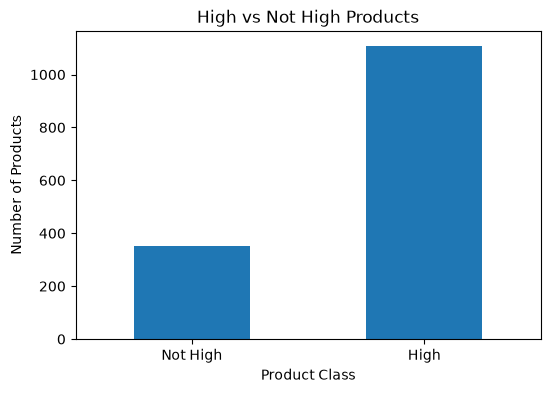

In [33]:
plt.figure(figsize=(6, 4))

df["High_Product"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("High vs Not High Products")
plt.xlabel("Product Class")
plt.ylabel("Number of Products")

plt.xticks(
    [0, 1],
    ["Not High", "High"],
    rotation=0
)

plt.show()

In [ ]:


features = [
    "discounted_price",
    "actual_price",
    "discount_percentage",
    "rating_count"
]

X = df[features]
y = df["High_Product"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,discounted_price,actual_price,discount_percentage,rating_count
0,399.0,1099.0,64,24269.0
1,199.0,349.0,43,43994.0
2,199.0,1899.0,90,7928.0
3,329.0,699.0,53,94363.0
4,154.0,399.0,61,16905.0



Target:


0    1
1    1
2    0
3    1
4    1
Name: High_Product, dtype: int64

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1169
Testing samples: 293


In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


In [37]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled, y_train)

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


In [38]:
y_pred = model.predict(X_test_scaled)

y_pred_proba = model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions:")
print(y_pred[:10])

Predictions:
[1 1 1 1 1 1 1 0 1 1]


In [39]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

print("========== MODEL PERFORMANCE ==========")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

========== MODEL PERFORMANCE ==========
Accuracy : 0.7884
Precision: 0.8125
Recall   : 0.9369
F1 Score : 0.8703


In [40]:
print("========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not High",
            "High"
        ],
        zero_division=0
    )
)

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

    Not High       0.62      0.32      0.43        71
        High       0.81      0.94      0.87       222

    accuracy                           0.79       293
   macro avg       0.72      0.63      0.65       293
weighted avg       0.77      0.79      0.76       293



Confusion Matrix:
[[ 23  48]
 [ 14 208]]


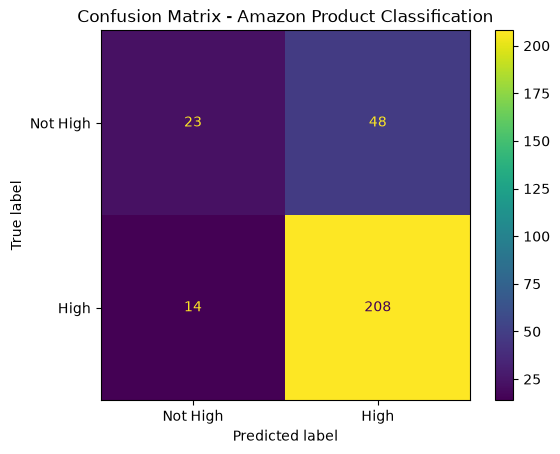

In [41]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Not High",
        "High"
    ]
)

disp.plot()

plt.title("Confusion Matrix - Amazon Product Classification")
plt.show()

In [42]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(
    ascending=False
)

print("========== FEATURE IMPORTANCE ==========")
print(feature_importance)

========== FEATURE IMPORTANCE ==========
rating_count           0.349682
discounted_price       0.224177
discount_percentage    0.222313
actual_price           0.203829
dtype: float64


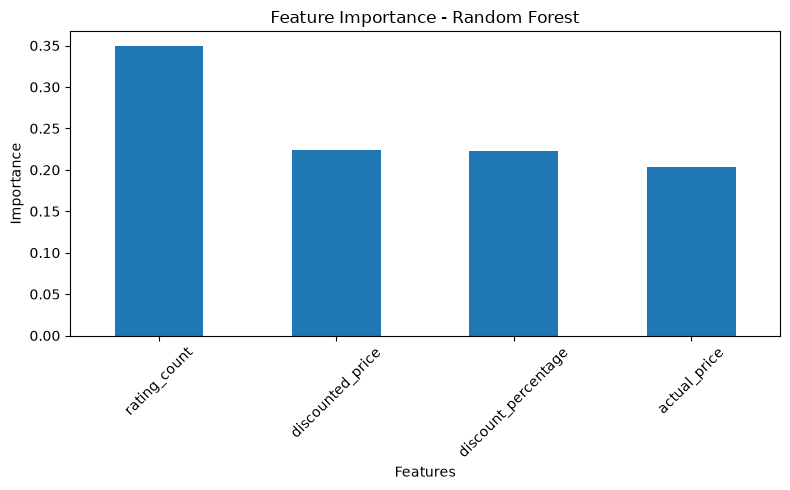

In [43]:
plt.figure(figsize=(8, 5))

feature_importance.plot(
    kind="bar"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [44]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_High": y_pred_proba
})

print("========== SAMPLE PREDICTIONS ==========")

display(results.head(10))

========== SAMPLE PREDICTIONS ==========


,Actual,Predicted,Probability_High
0,0,1,0.925129
1,1,1,0.621519
2,1,1,0.845547
3,1,1,0.610580
4,1,1,0.906146
5,1,1,0.976518
6,0,1,0.795326
7,0,0,0.471477
8,0,1,0.844991
9,1,1,0.787904


In [45]:
print("========== FINAL SUMMARY ==========")

print("Dataset Shape:", df.shape)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nTarget Definition:")
print("1 = High Product (Rating >= 4.0)")
print("0 = Not High Product (Rating < 4.0)")

========== FINAL SUMMARY ==========
Dataset Shape: (1462, 17)
Accuracy : 0.7884
Precision: 0.8125
Recall   : 0.9369
F1 Score : 0.8703

Target Definition:
1 = High Product (Rating >= 4.0)
0 = Not High Product (Rating < 4.0)
